<div style="border: 3px solid #1f6fb2; border-radius: 10px; padding: 52px 44px; text-align: center; background: linear-gradient(160deg, #f8fbff 0%, #e4f0fc 100%); margin-bottom: 8px;">
  <div style="font-size: 56px; font-weight: 900; color: #1f6fb2; letter-spacing: 4px; margin-bottom: 18px; font-family: sans-serif;">
    ICU SEPSIS RL
  </div>
  <div style="font-size: 20px; font-weight: 700; color: #1a3a5c; margin-bottom: 8px;">
    Clinical Treatment Optimisation: Sepsis ICU Management
  </div>
  <div style="font-size: 15px; font-style: italic; color: #4a6a8a; margin-bottom: 38px;">
    Configuration B – Deep Reinforcement Learning
  </div>
  <hr style="border: none; border-top: 2px solid #1f6fb2; width: 48%; margin: 0 auto 28px auto;">
  <div style="font-size: 14px; font-weight: 600; color: #1a3a5c; margin-bottom: 6px;">
    Ana Gonçalves &nbsp;|&nbsp; Catarina &nbsp;|&nbsp; Filipa São João &nbsp;|&nbsp; Inês Esteves &nbsp;|&nbsp; Maria
  </div>
  <div style="font-size: 13px; font-style: italic; color: #6a8aaa;">
    NOVA IMS – Master in Data Science &amp; Advanced Analytics - Reinforcement Learning - May 2026
  </div>
</div>


<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Environment Exploration](#3)
  - [3.1 Observation Space - 47 Physiological Features](#3_1)
  - [3.2 Random Baseline - Base Environment](#3_2)
  - [3.3 Random Baseline - Clinical Environment (Wrappers)](#3_3)
  - [3.4 Environment Comparison (Base vs Clinical)](#3_4)
  - [3.5 Feature Outcome Relationship](#3_5)
  - [3.6 Action Space — Treatment Intensity](#3_6)

# <font color='#2f94d7' size=6>**1. Project Overview - Config B**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [7]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import gymnasium as gym
import random
import time

import torch
import torch.nn as nn
#import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

warnings.filterwarnings('ignore')

# Project modules
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv,
    AcuteEventEnv, make_clinical_env
)

# Config B constants
OBS_DIM = 47   # 47 physiological features

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'


print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


Device: cpu
ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [8]:
# Config B observation constants
OBS_DIM  = 47   # 47 physiological features

In [6]:
# Verify wrapper stack order
test_env = make_clinical_env()
e = test_env
layers = []
while hasattr(e, 'env'):
    layers.append(type(e).__name__)
    e = e.env
layers.append(type(e).__name__)
test_env.close()


print()
print('Clinical environment wrapper stack (outer → inner):')
for i, layer in enumerate(layers):
    prefix = '  ' * i + ('└─ ' if i > 0 else '┌─ ')
    print(f'{prefix}{layer}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical environment wrapper stack (outer → inner):
┌─ AcuteEventEnv
  └─ EpisodicMissingObsEnv
    └─ EpisodicNoisyObsEnv
      └─ ContinuousICUSepsisEnv


In [9]:
# REPRODUCIBILITY
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# <font color='#2f94d7' size=6>**3. Environment Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**3.1 Observation Space — 47 Physiological Features**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

The cluster centres of the 714 non-terminal states are extracted directly from the environment. Each row is a normalised physiological feature vector that the agent observes.

In [10]:
# Build the base continuous env and extract cluster centres
base_env = ContinuousICUSepsisEnv(params=make_sepsis_env())

# Shape: (716, 47).  Rows 714 and 715 are terminal states — drop them.
all_centers = base_env._cluster_centers          # (716, 47)
clinical_centers = all_centers[:714]             # (714, 47) — non-terminal only

df_states = pd.DataFrame(clinical_centers, columns=FEATURE_NAMES)

print()
print(f'Clinical state matrix shape : {clinical_centers.shape}')
print('Summary statistics (first 8 features):')
df_states.describe().T.head(8).round(3)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Clinical state matrix shape : (714, 47)
Summary statistics (first 8 features):


,count,mean,std,min,25%,50%,75%,max
Albumin,714.0,-0.061,0.125,-0.479,-0.148,-0.060,0.022,0.327
ALP,714.0,-0.134,0.289,-0.500,-0.373,-0.225,0.079,0.500
ALT,714.0,-0.425,0.213,-0.500,-0.496,-0.479,-0.434,3.722
AST,714.0,0.449,0.165,0.000,0.335,0.426,0.538,1.100
Bilirubin,714.0,-0.020,0.579,-2.166,-0.355,0.068,0.412,1.094
BUN,714.0,0.034,0.629,-0.825,-0.263,-0.068,0.140,5.403
Chloride,714.0,-0.055,0.746,-2.521,-0.224,0.256,0.436,0.672
Creatinine,714.0,0.064,0.695,-1.276,-0.495,-0.044,0.578,2.221


The base environment exposes a (714, 47) matrix of cluster centres,
one centroid per non-terminal clinical state, with 47 physiological
features each (the same variables used in Komorowski et al. 2018).

**Key observations:**
- All 714 states have complete feature vectors (no missing values in
  the state representation itself)
- Features are approximately centred at 0, confirming normalisation, so
  no additional preprocessing is needed before feeding observations to
  a neural network
- Some features show high maximum values (e.g. BUN, ALT), reflecting
  clusters of patients in critical condition, expected in an ICU setting

The 714 × 47 continuous state space makes tabular methods infeasible,
motivating the use of function approximation in Config B.

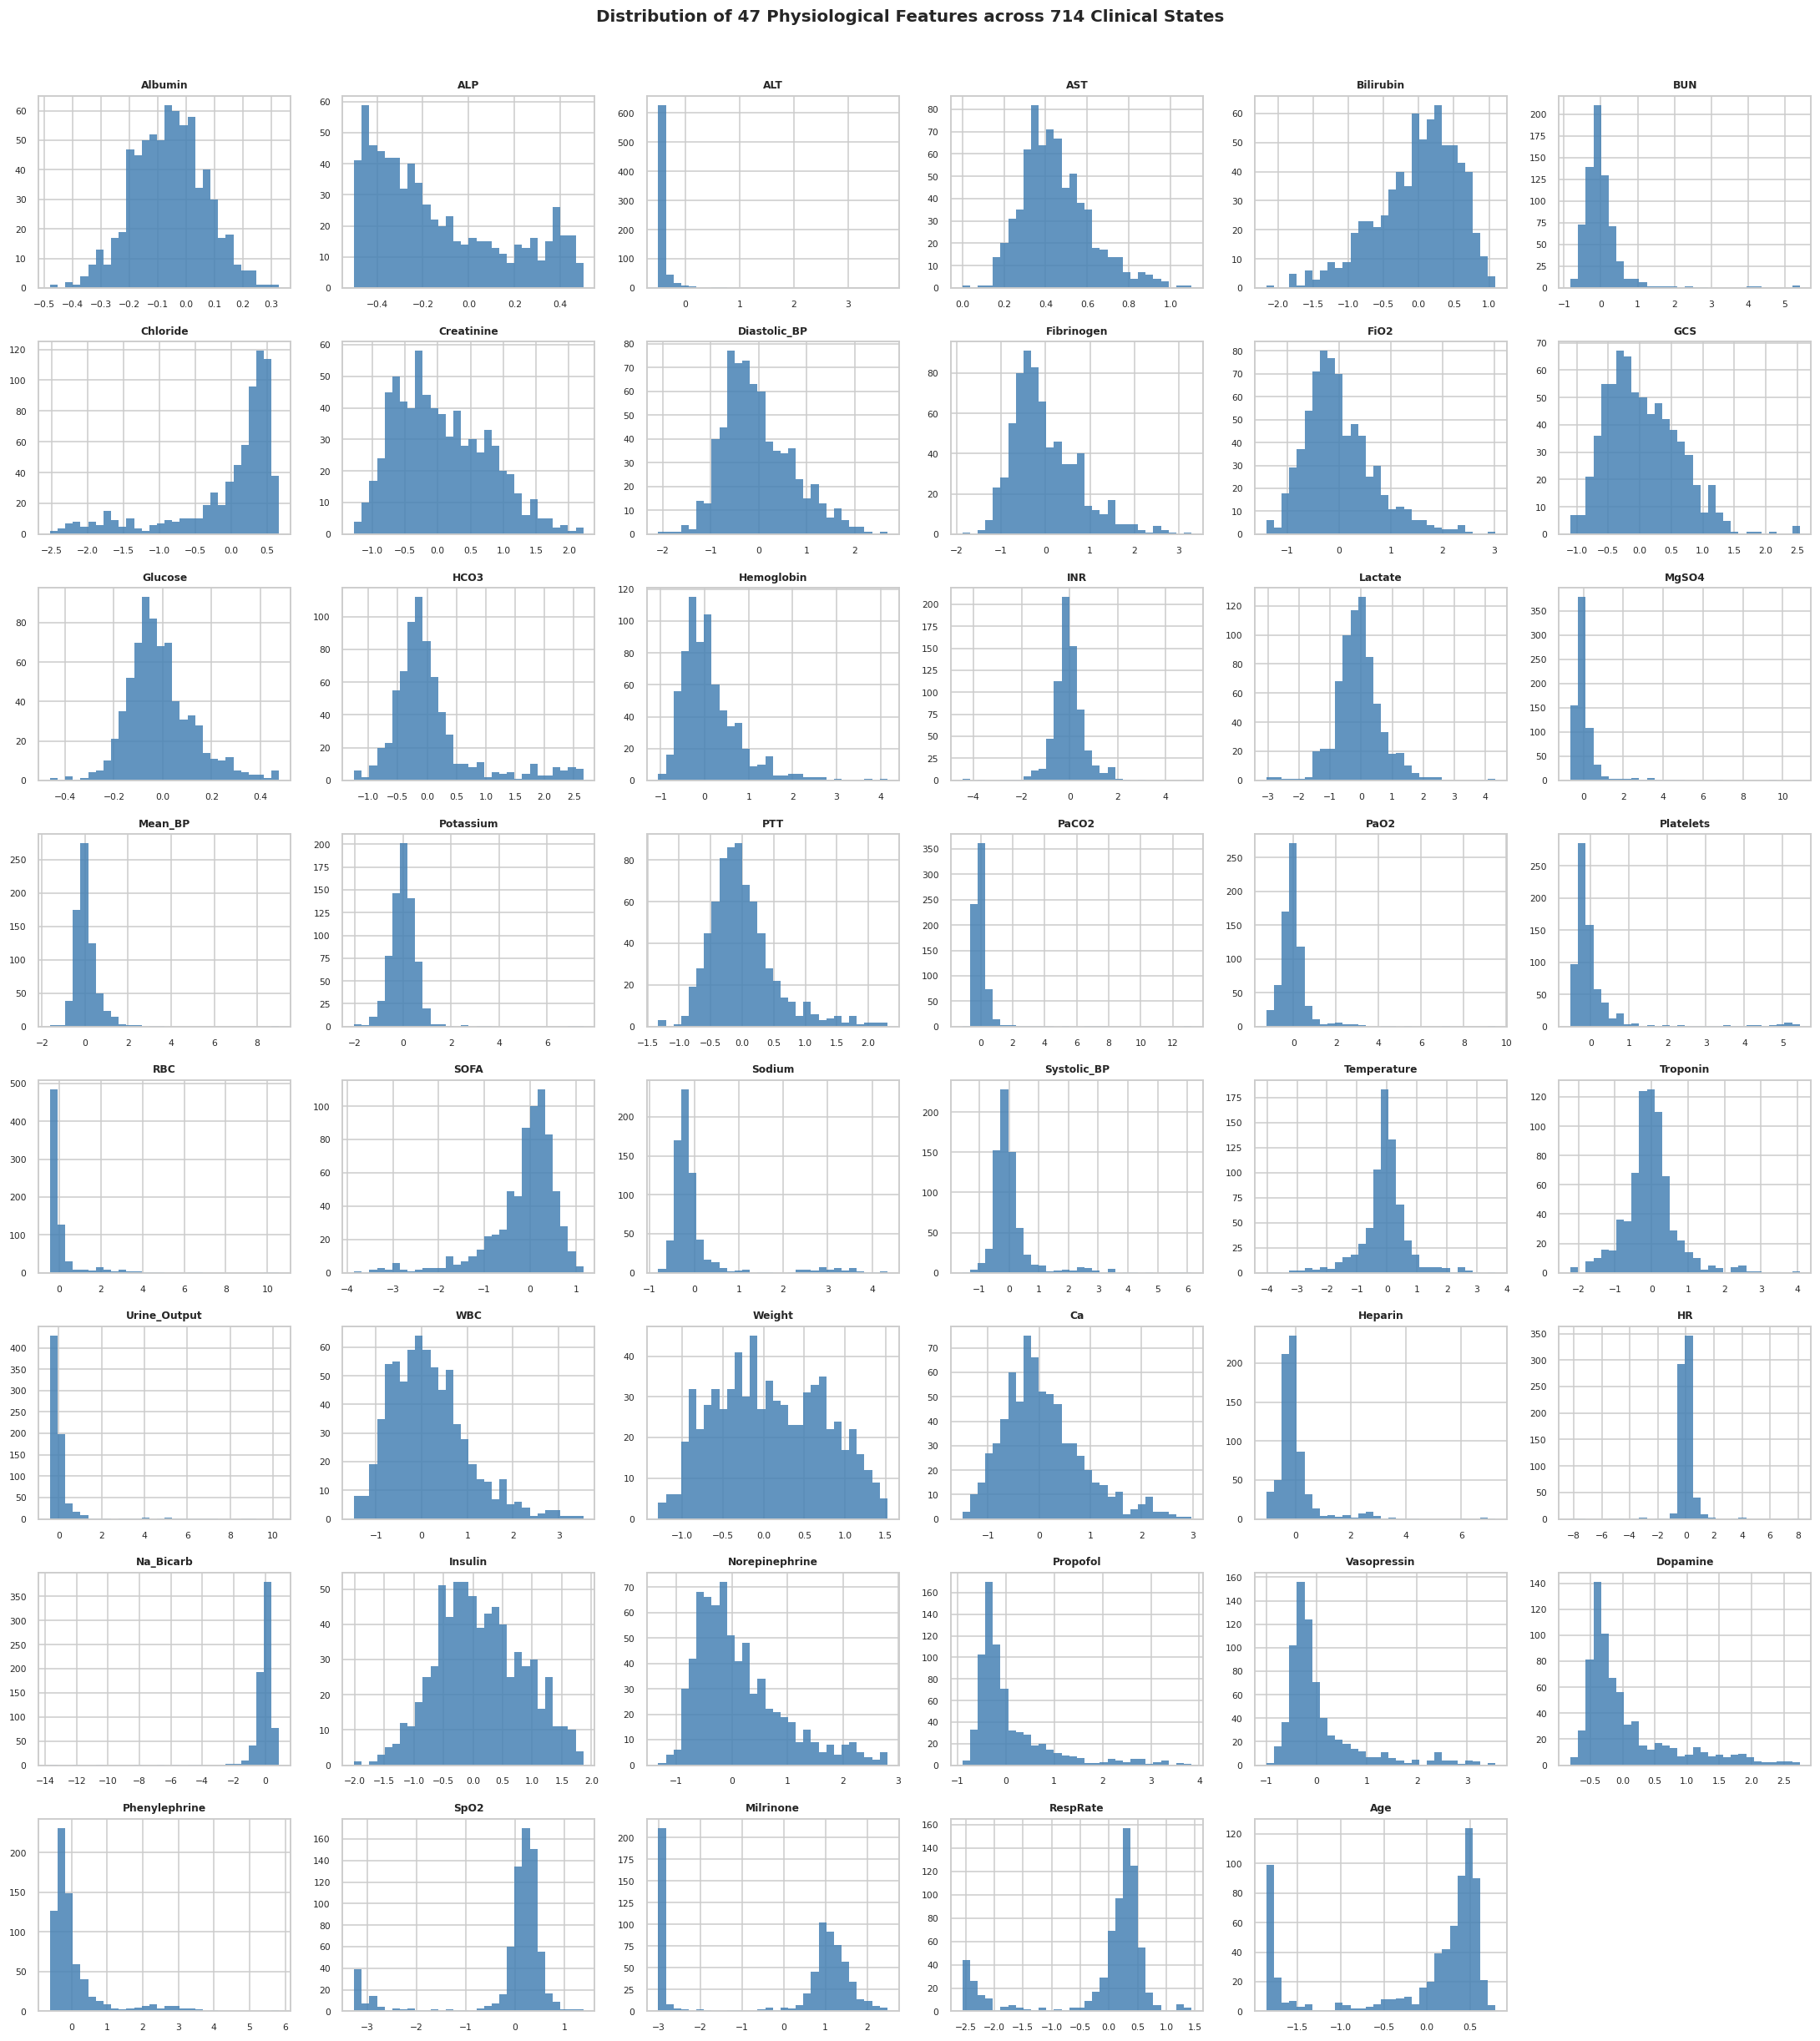

In [11]:
# Distribution of all 47 features across states
fig, axes = plt.subplots(8, 6, figsize=(20, 22))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_states[feat], bins=30, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

# hide spare axes (47 features, 48 subplots)
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of 47 Physiological Features across 714 Clinical States',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The 47 physiological features show a lot of right-skewed distributions typical
of ICU data, most patients cluster around normal values, with a minority
in critical states driving extreme observations. Several treatment-related
features (e.g. Milrinone, Vasopressin, Norepinephrine) are zero for most
states, reflecting that aggressive interventions are used selectively.

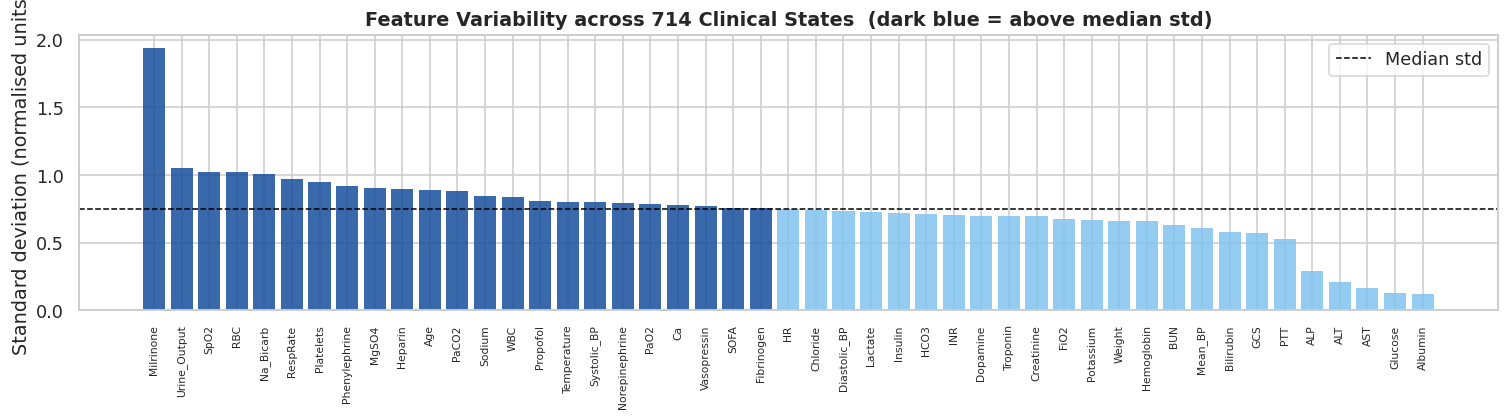

In [12]:
# Feature variance ranking
feat_std = df_states.std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#164f9b" if s > feat_std.median() else "#81c2ee" for s in feat_std]
ax.bar(feat_std.index, feat_std.values, color=colors, edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(feat_std)))
ax.set_xticklabels(feat_std.index, rotation=90, fontsize=7)
ax.set_ylabel('Standard deviation (normalised units)')
ax.set_title('Feature Variability across 714 Clinical States  '
             '(dark blue = above median std)', fontweight='bold')
ax.axhline(feat_std.median(), color='black', ls='--', lw=1, label='Median std')
ax.legend()
plt.tight_layout()
plt.show()

Features vary substantially in how much they differ across the 714 clinical
states. High-variability features (e.g. Milrinone, Urine_Output, SpO2,
RBC) are more discriminative between states (red bars), while low-variability features
(e.g. Albumin, Glucose, AST) contribute less to distinguishing clinical
conditions (blue bars). This suggests the observation space contains redundancy,
not all 47 features carry equal information for the agent.

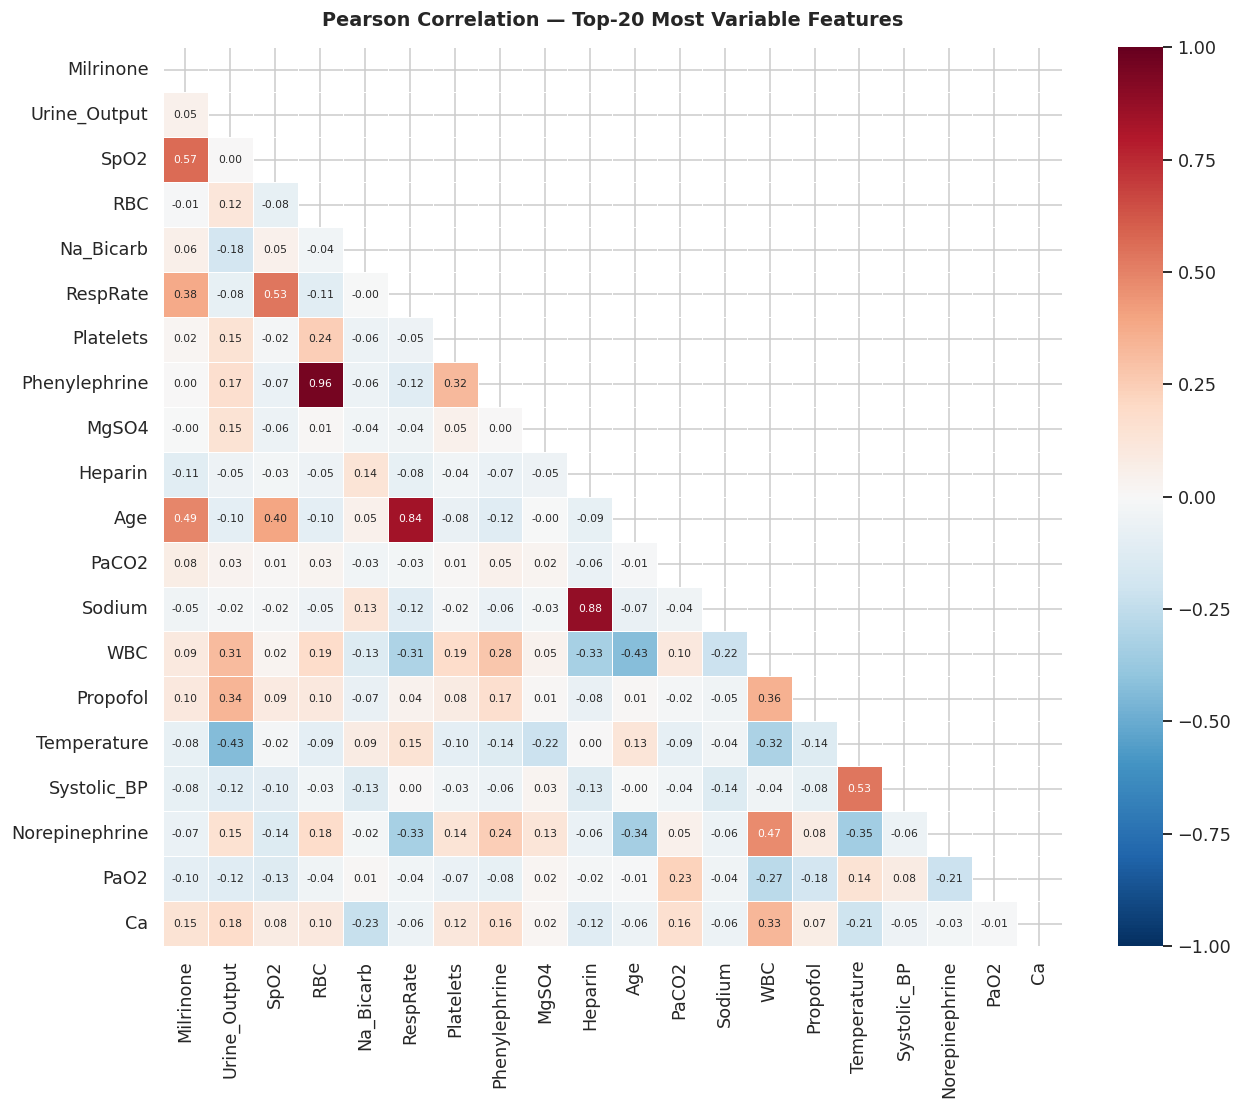

In [13]:
# Correlation heatmap (top-20 most variable features)
top20 = feat_std.head(20).index.tolist()
corr  = df_states[top20].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.4, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation — Top-20 Most Variable Features',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

Most feature pairs are weakly correlated, meaning the observation vector
carries largely complementary information. However, three pairs show
notably high correlation:
- **RBC - Phenylephrine (r=0.96)** — near-redundant features
- **Sodium - Heparin (r=0.88)** — strong association between
  electrolyte levels and anticoagulation treatment
- **Age - RespRate (r=0.84)** — older patients tend to present higher
  respiratory rates, reflecting reduced physiological reserve

These correlations are unlikely to cause problems for a neural network
but are worth noting as sources of redundancy in the input space.

## <font color='#2f94d7' size=6>**3.2 Random Baseline - Base Environment**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

We roll out `N_EPISODES = 1000` episodes using a uniformly random policy to characterise baseline episode length, survival rate, and reward distribution **before any learning**.


> **Note:** results vary slightly between runs as each episode is initialised
> with a different random seed. Values reported reflect typical observed ranges.

In [14]:
# Random-policy rollouts on the clean base env

N_EPISODES = 1000   # episodes for random-policy rollouts

def rollout(env, n_episodes: int, seed: int = SEED):
    """Run n_episodes with a random policy. Return a list of episode dicts."""
    rng = np.random.default_rng(seed)
    records = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=int(rng.integers(1_000_000)))
        ep_return, ep_len, done = 0.0, 0, False
        obs_traj = [obs]
        while not done:
            action = env.action_space.sample()
            obs, r, te, tr, info = env.step(action)
            ep_return += r
            ep_len    += 1
            done = te or tr
            obs_traj.append(obs)
        records.append({
            'episode'   : ep,
            'return'    : ep_return,
            'length'    : ep_len,
            'survived'  : ep_return > 0,
            'obs_traj'  : np.array(obs_traj[:-1]),   # exclude terminal
            **{k: v for k, v in info.items()},
        })
    return records


print('Rolling out random policy on clean base env:')
records_clean = rollout(base_env, N_EPISODES)
df_ep = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                       for r in records_clean])

survival_rate = df_ep['survived'].mean()
mean_length   = df_ep['length'].mean()
print(f'Random policy  |  Survival rate: {survival_rate:.1%}  '
      f'|  Mean episode length: {mean_length:.1f} steps')

Rolling out random policy on clean base env:
Random policy  |  Survival rate: 72.8%  |  Mean episode length: 9.9 steps


With this results it's possible to understand that each episode simulates a sequence of ~10 treatment decisions (vasopressor + IV fluid dose). Any trained agent must exceed the survival rate recorded
here to demonstrate meaningful learning.

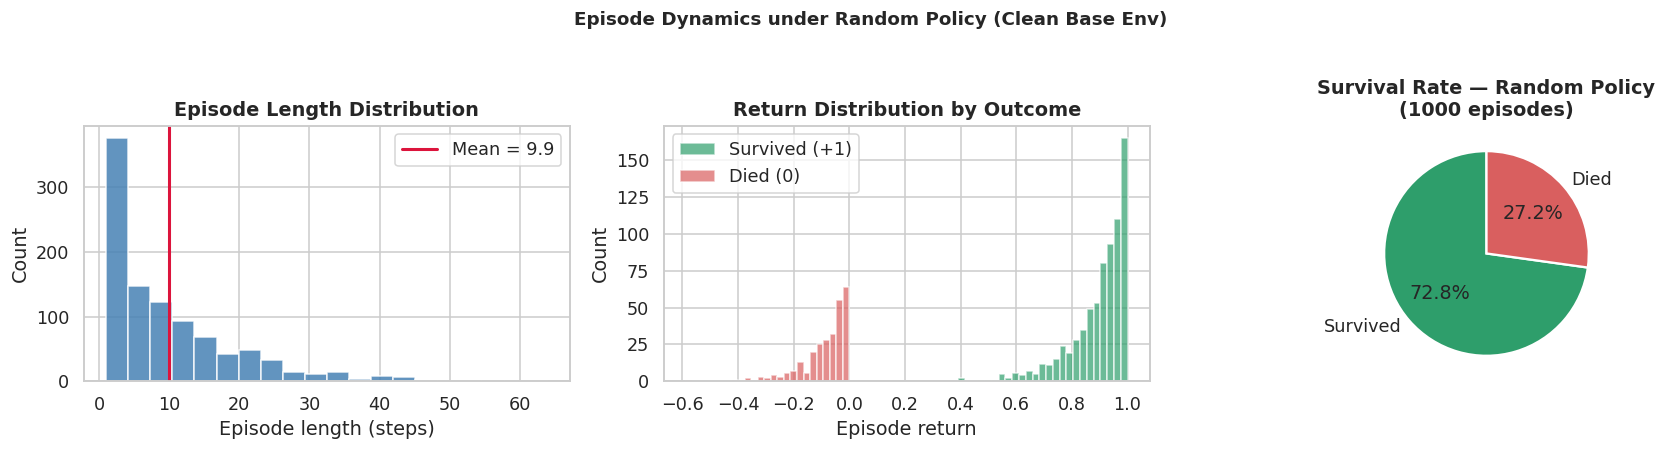

In [15]:
# Episode length & return distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Episode length
axes[0].hist(df_ep['length'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mean_length, color='crimson', lw=2, label=f'Mean = {mean_length:.1f}')
axes[0].set_xlabel('Episode length (steps)')
axes[0].set_ylabel('Count')
axes[0].set_title('Episode Length Distribution', fontweight='bold')
axes[0].legend()

# Return distribution
survived_col = df_ep['survived'].map({True: 'Survived (+1)', False: 'Died (0)'})
for outcome, colour in [('Survived (+1)', '#2E9E6B'), ('Died (0)', '#D95F5F')]:
    mask = survived_col == outcome
    axes[1].hist(df_ep.loc[mask, 'return'], bins=25,
                 label=outcome, color=colour, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Episode return')
axes[1].set_ylabel('Count')
axes[1].set_title('Return Distribution by Outcome', fontweight='bold')
axes[1].legend()

# Survival pie
counts = df_ep['survived'].value_counts()
axes[2].pie(
    [counts.get(True, 0), counts.get(False, 0)],
    labels=['Survived', 'Died'],
    colors=["#2E9E6B", "#D95F5F"],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title(f'Survival Rate — Random Policy\n({N_EPISODES} episodes)',
                  fontweight='bold')

plt.suptitle('Episode Dynamics under Random Policy (Clean Base Env)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Episode length:** is right-skewed, most episodes resolve in fewer than 10
steps, though a long tail exists where patients take much longer to stabilise
or deteriorate. The mean episode length is ~10 steps.

**Return distribution by Outcome:** shows two clear clusters: episodes ending in death
concentrate near 0, while survival episodes cluster close to 1.0 but rarely
reach it exactly, the treatment intensity penalty (lam=0.02) accumulates
across steps and slightly reduces the final return even in survived episodes.

**Survival rate: ~72%** under a random policy on the clean environment.
This is the performance floor for the base environment — trained agents
must exceed this to demonstrate meaningful learning.

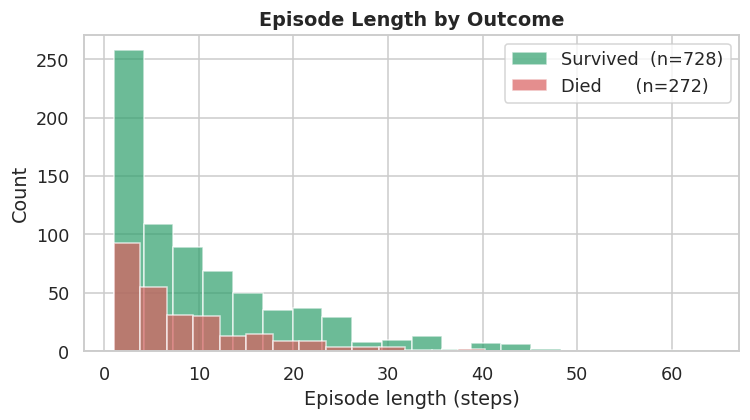

Survived — mean length: 10.46  std: 10.02
Died     — mean length: 8.54  std: 8.29


In [16]:
# Episode length by outcome
fig, ax = plt.subplots(figsize=(7, 4))
survived_lengths = df_ep.loc[df_ep['survived'],  'length']
died_lengths     = df_ep.loc[~df_ep['survived'], 'length']

ax.hist(survived_lengths, bins=20, alpha=0.7, color="#2E9E6B",
        label=f'Survived  (n={len(survived_lengths)})', edgecolor='white')
ax.hist(died_lengths,     bins=20, alpha=0.7, color="#D95F5F",
        label=f'Died      (n={len(died_lengths)})',     edgecolor='white')
ax.set_xlabel('Episode length (steps)')
ax.set_ylabel('Count')
ax.set_title('Episode Length by Outcome', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Survived — mean length: {survived_lengths.mean():.2f}  '
      f'std: {survived_lengths.std():.2f}')
print(f'Died     — mean length: {died_lengths.mean():.2f}  '
      f'std: {died_lengths.std():.2f}')

Survived and died episodes show nearly identical length distributions
(survived: mean ~10.5 steps, died: mean ~9.9 steps), with high variability
in both groups (std ~ 10).

This confirms that under a random policy, episode length is not predictive
of outcome, a patient can die quickly or after many steps regardless of
how many treatment decisions were made. What matters is the **quality** of
those decisions, not the quantity.

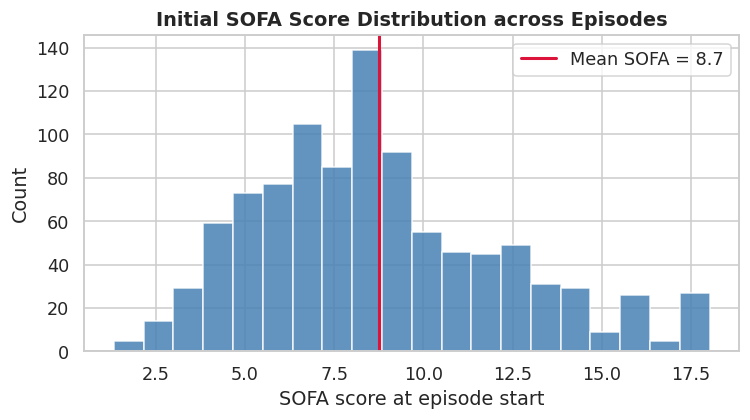

Mean SOFA : 8.75
Std SOFA  : 3.49
Min SOFA  : 1
Max SOFA  : 18


In [17]:
# SOFA score distribution at episode start
sofa_scores = []
rng_sofa = np.random.default_rng(SEED)
for i in range(N_EPISODES):
    _, info = base_env.reset(seed=int(rng_sofa.integers(1_000_000)))
    sofa_scores.append(info['sofa_score'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sofa_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sofa_scores), color='crimson', lw=2,
           label=f'Mean SOFA = {np.mean(sofa_scores):.1f}')
ax.set_xlabel('SOFA score at episode start')
ax.set_ylabel('Count')
ax.set_title('Initial SOFA Score Distribution across Episodes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean SOFA : {np.mean(sofa_scores):.2f}')
print(f'Std SOFA  : {np.std(sofa_scores):.2f}')
print(f'Min SOFA  : {np.min(sofa_scores):.0f}')
print(f'Max SOFA  : {np.max(sofa_scores):.0f}')

The SOFA (Sequential Organ Failure Assessment) score measures organ failure
severity at the start of each episode. Higher values indicate more critical
patients and in clinical practice, scores above 8 are associated with high
mortality risk.

**Key statistics:** mean 8.75, std 3.49, range [1, 18]

The distribution is approximately bell-shaped, with most episodes starting
between SOFA 5 and 12. This reflects the `sofa_bias=5.0` parameter in the
environment, which deliberately skews the patient population towards more
severe cases.

This confirms that the agent always starts from a difficult
clinical situation, it is never treating mild cases, which justifies the
complexity of the learning problem ahead.

## <font color='#2f94d7' size=6>**3.3 Random Baseline - Clinical Environment (Wrappers Env)**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

> **Note:** results vary slightly between runs due to two sources of
> stochasticity: random episode seeds (as in section 3.2) and the
> probabilistic clinical wrappers (noisy observations at 15% of episodes,
> missing features at 15% of episodes). Values reported reflect typical
> observed ranges.

In [18]:
# Reuse rollout() on the clinical environment (with wrappers)
clinical_env = make_clinical_env()
records_clinical = rollout(clinical_env, N_EPISODES)
clinical_env.close()

print()

df_clinical = pd.DataFrame([{k: v for k, v in r.items() if k != 'obs_traj'}
                             for r in records_clinical])

clinical_rand_mean = df_clinical['return'].mean()
survival_clinical  = df_clinical['survived'].mean() * 100

noisy_mask   = df_clinical['noisy_episode'] == True
missing_mask = df_clinical['missing_features'].notna()

print(f'Random Baseline: Clinical Environment ({N_EPISODES} episodes):')
print(f'  Overall mean reward return : {clinical_rand_mean:.4f}')
print(f'  Overall survival rate      : {survival_clinical:.1f}%')
print()
print(f'Breakdown by wrapper condition:')
print(f'  Noisy episodes        : {noisy_mask.sum():>4}  | mean reward return: {df_clinical.loc[noisy_mask, "return"].mean():.4f}')
print(f'  Clean episodes        : {(~noisy_mask).sum():>4}  | mean reward return: {df_clinical.loc[~noisy_mask, "return"].mean():.4f}')
print(f'  Missing obs episodes  : {missing_mask.sum():>4}  | mean reward return: {df_clinical.loc[missing_mask, "return"].mean():.4f}')
print(f'  Complete obs episodes : {(~missing_mask).sum():>4}  | mean reward return: {df_clinical.loc[~missing_mask, "return"].mean():.4f}')
print()
print(f'  >> Trained agents must exceed survival rate > {survival_clinical:.1f}% and mean reward return > {clinical_rand_mean:.4f}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Random Baseline: Clinical Environment (1000 episodes):
  Overall mean reward return : 0.5901
  Overall survival rate      : 68.4%

Breakdown by wrapper condition:
  Noisy episodes        :  149  | mean reward return: 0.6714
  Clean episodes        :  851  | mean reward return: 0.5759
  Missing obs episodes  :  153  | mean reward return: 0.5648
  Complete obs episodes :  847  | mean reward return: 0.5947

  >> Trained agents must exceed survival rate > 68.4% and mean reward return > 0.5901


**Key results:**
- Survival rate: ~65–68% | Mean return: ~0.56–0.59

**Effect of clinical wrappers (on the random agent):**
- Noisy observations and missing features consistently produce slightly lower
  returns than clean episodes, confirming the wrappers make the problem
  harder, as intended.

Trained agents will be evaluated against this same environment and must
exceed the mean return stored in `clinical_rand_mean`.

## <font color='#2f94d7' size=6>**3.4 Environment Comparison (Base vs Clinical)**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)


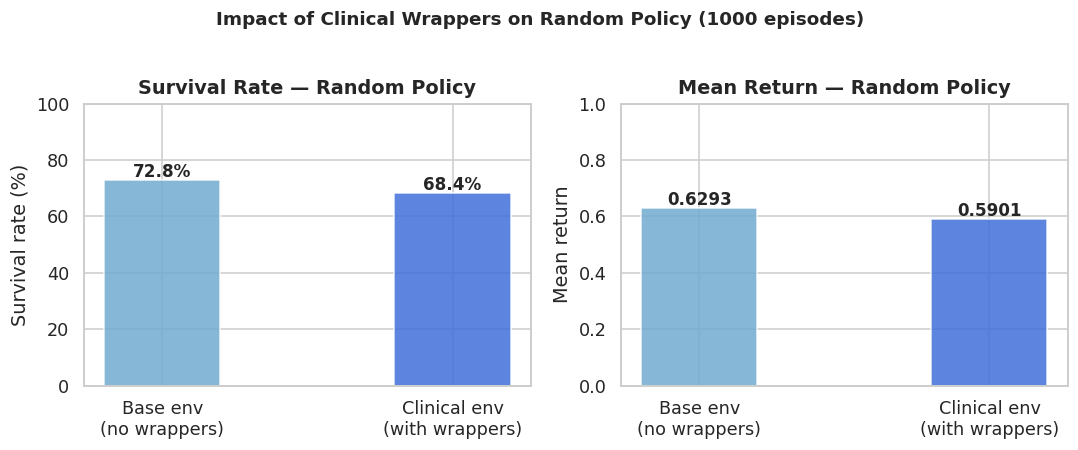

Survival rate drop : 4.4 pp
Mean return drop   : 0.0392


In [19]:
# Direct comparison: clean base env vs clinical env (with wrappers)
base_survival  = df_ep['survived'].mean() * 100
base_return    = df_ep['return'].mean()
clinical_survival = df_clinical['survived'].mean() * 100
clinical_return   = df_clinical['return'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Survival rate comparison
envs   = ['Base env\n(no wrappers)', 'Clinical env\n(with wrappers)']
colors = ["#72abd1", "#4170db"]

axes[0].bar(envs, [base_survival, clinical_survival],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[0].set_ylabel('Survival rate (%)')
axes[0].set_title('Survival Rate — Random Policy', fontweight='bold')
axes[0].set_ylim(0, 100)
for i, v in enumerate([base_survival, clinical_survival]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Mean return comparison
axes[1].bar(envs, [base_return, clinical_return],
            color=colors, edgecolor='white', alpha=0.85, width=0.4)
axes[1].set_ylabel('Mean return')
axes[1].set_title('Mean Return — Random Policy', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate([base_return, clinical_return]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Impact of Clinical Wrappers on Random Policy ({N_EPISODES} episodes)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Survival rate drop : {base_survival - clinical_survival:.1f} pp')
print(f'Mean return drop   : {base_return - clinical_return:.4f}')

Comparing the random policy across both environments makes the impact of
the clinical wrappers immediately visible.

**Survival rate** drops from ~71% (base) to ~65% (clinical) — a drop
of ~6 percentage points and **mean return** drops from ~0.62 to ~0.57.

This confirms that the three wrappers (noisy observations, missing features,
and acute events) collectively make the problem meaningfully harder, as
intended. Any trained agent will need to be robust to these conditions to
perform well in the clinical environment.

> **Note:** the exact drop values vary between runs due to stochasticity
> in both environments. The direction of the effect (base > clinical) is
> consistent across runs.

## <font color='#2f94d7' size=6>**3.5 Feature–Outcome Relationship**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Collect the *initial* observation of each episode (i.e., the patient state at admission) and test whether any features differ significantly between patients who survive and those who die.

In [20]:
# Build a DataFrame of initial obs per episode
init_obs = np.vstack([r['obs_traj'][0] for r in records_clean])
df_init  = pd.DataFrame(init_obs, columns=FEATURE_NAMES)
df_init['survived'] = df_ep['survived'].values

# Mean difference between survivors and non-survivors at episode start
diff = (df_init.groupby('survived')[FEATURE_NAMES].mean()
        .T.assign(delta=lambda d: d[True] - d[False])
        .sort_values('delta'))

print('Top-5 features higher in survivors at episode start:')
print(diff['delta'].tail(5).round(4))
print('\nTop-5 features higher in non-survivors at episode start:')
print(diff['delta'].head(5).round(4))

Top-5 features higher in survivors at episode start:
Chloride        0.3131
Temperature     0.3293
Diastolic_BP    0.3330
SOFA            0.3713
Na_Bicarb       0.4049
Name: delta, dtype: float32

Top-5 features higher in non-survivors at episode start:
Urine_Output   -0.8726
WBC            -0.5652
Milrinone      -0.4560
Ca             -0.4238
Propofol       -0.3118
Name: delta, dtype: float32


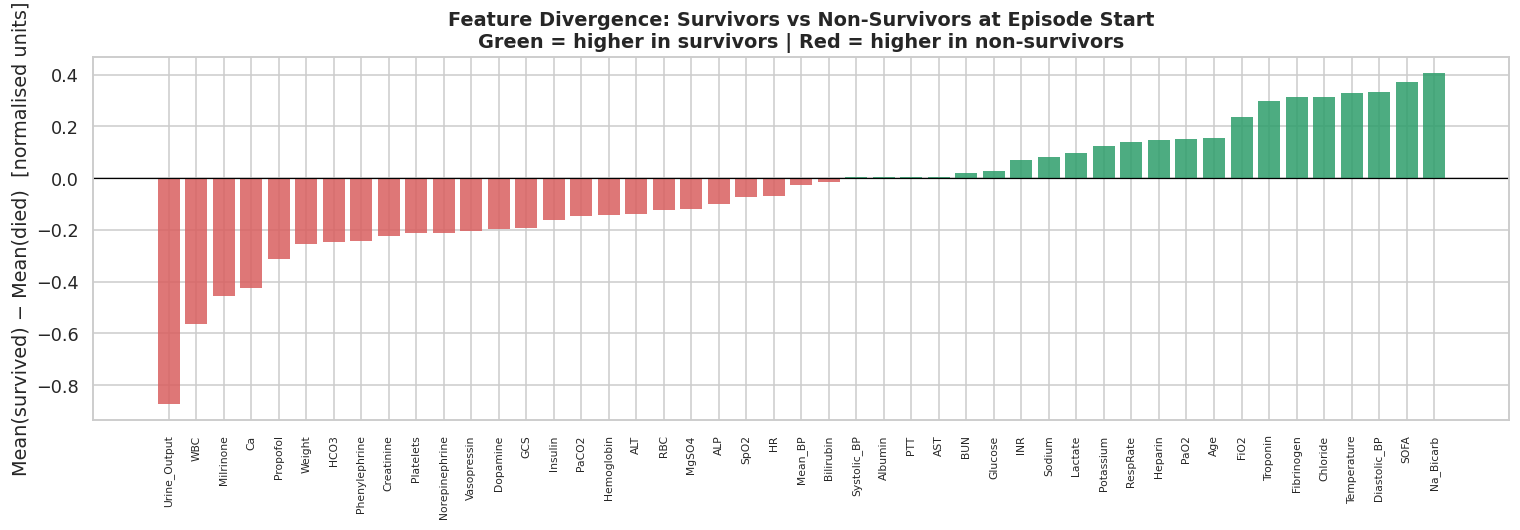

In [21]:
# Divergence bar chart
fig, ax = plt.subplots(figsize=(14, 5))

delta = diff['delta']
colors_bar = ["#2E9E6B" if v > 0 else "#D95F5F" for v in delta]
ax.bar(delta.index, delta.values, color=colors_bar, edgecolor='none', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(delta)))
ax.set_xticklabels(delta.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean(survived) − Mean(died)  [normalised units]')
ax.set_title('Feature Divergence: Survivors vs Non-Survivors at Episode Start\n'
             'Green = higher in survivors | Red = higher in non-survivors',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Top features higher in survivors:**
- **Na_Bicarb** and **Diastolic_BP:** higher bicarbonate and blood
  pressure suggest better cardiovascular and metabolic stability
- **Temperature** and **Fibrinogen:** reflect active immune response,
  which can be protective in early sepsis

**Top features higher in non-survivors:**
- **Urine_Output:** is the most divergent feature, very low urine output
  in non-survivors indicates kidney failure, a strong predictor of ICU
  mortality
- **WBC:** (white blood cells) is elevated in non-survivors, reflecting
  severe systemic inflammation
- **Milrinone** and **Propofol:** the higher use of these drugs in
  non-survivors suggests they were already in more critical condition
  requiring aggressive intervention

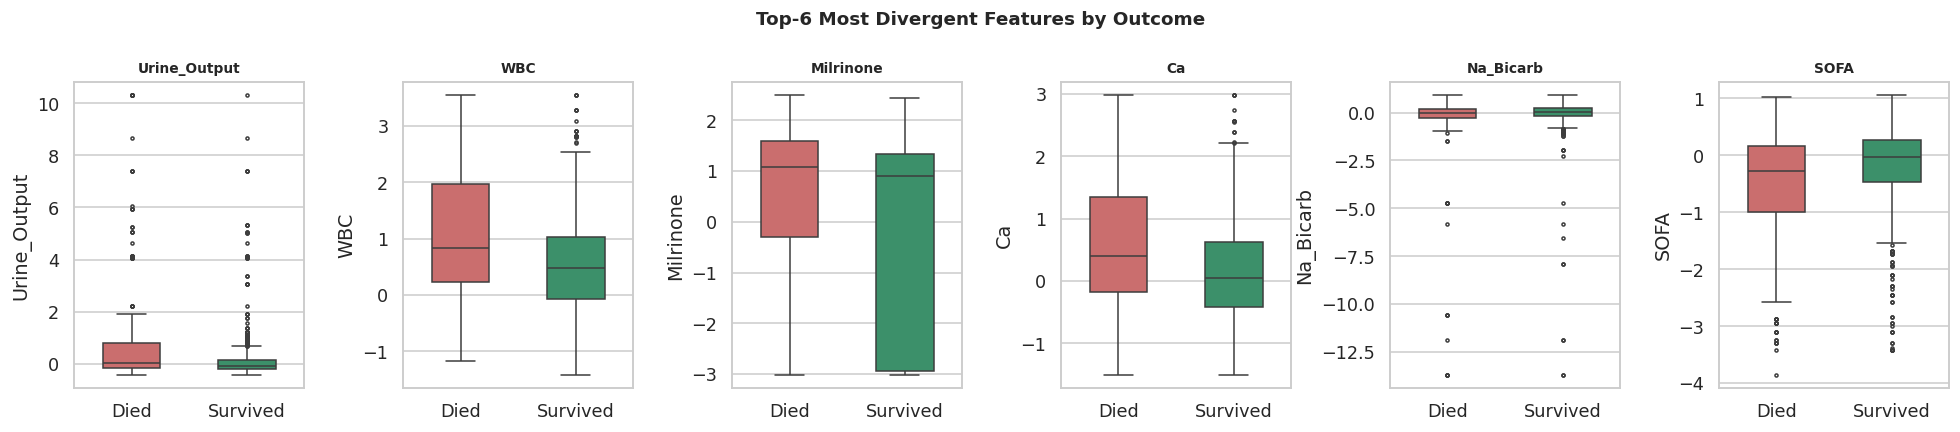

In [22]:
# Box-plots for top-6 most divergent features
top6 = diff['delta'].abs().sort_values(ascending=False).head(6).index.tolist()

# Convert boolean to string labels so seaborn palette keys match
df_plot = df_init.copy()
df_plot['outcome'] = df_plot['survived'].map({True: 'Survived', False: 'Died'})

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=False)
palette = {'Survived': "#2E9E6B", 'Died':     "#D95F5F" }

for ax, feat in zip(axes, top6):
    sns.boxplot(
        data=df_plot, x='outcome', y=feat,
        order=['Died', 'Survived'],
        palette=palette, width=0.5, fliersize=2, ax=ax
    )
    ax.set_xlabel('')
    ax.set_title(feat, fontweight='bold', fontsize=9)

fig.suptitle('Top-6 Most Divergent Features by Outcome',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots confirm these differences visually. Urine_Output and WBC show
the clearest separation between outcomes, while other features (e.g.
Na_Bicarb, Milrinone) show more overlap and higher variance.

> **Note:** these are correlations at episode start under a random policy,
> not causal relationships. A trained agent should learn to act on these
> signals to improve survival outcomes.

## <font color='#2f94d7' size=6>**3.6 Action Space — Treatment Intensity**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

The 25 actions encode all combinations of 5 vasopressor levels × 5 IV fluid levels.  
A treatment intensity penalty `λ` is subtracted from the reward at each step, so it is useful to visualise the intensity landscape.

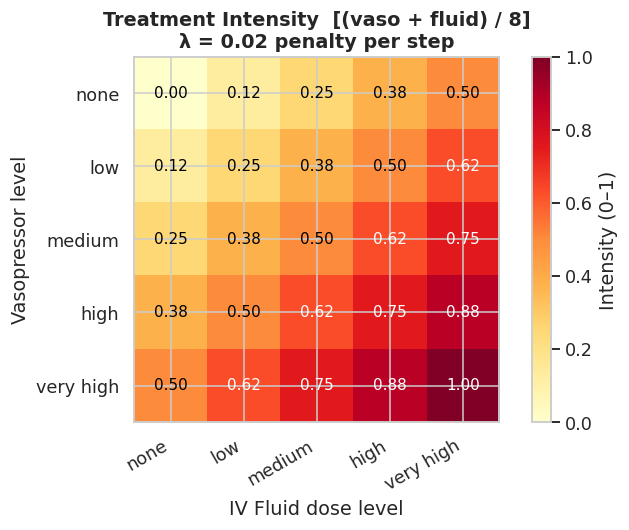

In [23]:
# Treatment intensity heatmap
levels = ['none', 'low', 'medium', 'high', 'very high']
intensity_matrix = np.array(
    [[(v + f) / 8.0 for f in range(5)] for v in range(5)]
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(intensity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(levels, rotation=30, ha='right')
ax.set_yticklabels(levels)
ax.set_xlabel('IV Fluid dose level')
ax.set_ylabel('Vasopressor level')
ax.set_title(f'Treatment Intensity  [(vaso + fluid) / 8]\nλ = {LAM} penalty per step',
             fontweight='bold')

for i in range(5):
    for j in range(5):
        val = intensity_matrix[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, color='white' if val > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Intensity (0–1)')
plt.tight_layout()
plt.show()

The 25 discrete actions encode all combinations of 5 vasopressor levels
× 5 IV fluid dose levels. The heatmap shows the treatment intensity score
for each action, defined as (vasopressor + fluid) / 8, ranging from 0.00
(no treatment) to 1.00 (maximum of both).

At each step, the agent receives a penalty of **λ = 0.02 × intensity**
subtracted from the reward. This means:
- **Low-intensity actions** (top-left of the heatmap) incur little penalty
- **High-intensity actions** (bottom-right) are progressively penalised

This penalty is intentional, it discourages the agent from administering
unnecessary treatment. A good policy must therefore balance maximising
survival (reward +1) against minimising treatment intensity (penalty
accumulation). An agent that always gives maximum treatment will survive
more episodes but accumulate heavy penalties, while an agent that never
treats will let patients die. The optimal policy lies somewhere in between.

# <font color='#2f94d7' size=6>**4. Algorithm 1 - DQN (Deep Q-Network)**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

### 2.1 Rationale & Architecture

**Why DQN?**

DQN is the natural extension of Q-Learning to continuous state spaces. In Config A, we stored Q(s,a) values in a 716×25 table. In Config B, with 47-dimensional continuous observations, the state space is effectively infinite — a table would need an entry for every unique float vector the agent might encounter.

DQN replaces the Q-table with a neural network `Q_θ(s,a)` that *approximates* the Q-value for any input state. The key innovations (DeepMind, 2015) that make training stable are:

1. **Experience Replay Buffer**: stores past transitions `(s, a, r, s', done)` and samples mini-batches to break temporal correlations between consecutive updates.
2. **Target Network**: a periodically-updated copy of the online network used to compute TD targets, preventing oscillations from the moving target problem.

**Bellman connection** (same as Q-Learning):
$$Q_\theta(s,a) \leftarrow r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$
where $\theta^-$ are the target network parameters.

**Architecture choice:**
- Input layer: 47 features
- Two hidden layers: 256 units each, with LayerNorm + ReLU  
  (LayerNorm handles the different feature scales without explicit normalization)
- Output layer: 25 Q-values (one per action)
- Loss: MSE between predicted Q and TD target

In [24]:
#  DQN — Neural Network & Replay Buffer

class QNetwork(nn.Module):
    """
    Q-value approximator: Q(s, a) for all 25 actions simultaneously.

    LayerNorm after each hidden layer handles the different scales of the
    47 physiological features without requiring explicit observation normalization.
    """
    def __init__(self, obs_dim: int = OBS_DIM, n_actions: int = N_ACTIONS, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ReplayBuffer:
    """
    Fixed-capacity circular buffer storing (s, a, r, s', done) transitions.
    Samples uniform random mini-batches to break temporal correlations.
    """
    def __init__(self, capacity: int = 100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


# Quick architecture summary
net_test = QNetwork()
n_params = sum(p.numel() for p in net_test.parameters())
print(f'QNetwork architecture:')
print(net_test)
print(f'\nTotal parameters: {n_params:,}')
test_out = net_test(torch.zeros(1, OBS_DIM))
print(f'Output shape (batch=1): {test_out.shape}  → one Q-value per action')

QNetwork architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=25, bias=True)
  )
)

Total parameters: 85,529
Output shape (batch=1): torch.Size([1, 25])  → one Q-value per action


In [25]:
#  DQN — Hyperparameters & Training

# Hyperparameters
DQN_EPISODES    = 25_000   # total training episodes
BUFFER_CAPACITY = 100_000  # replay buffer size
BATCH_SIZE      = 64       # mini-batch size
LR              = 1e-3     # learning rate
GAMMA_DQN       = GAMMA    # discount factor (1.0)
EPS_START       = 1.0      # initial exploration rate
EPS_END         = 0.05     # minimum exploration rate
EPS_DECAY       = 0.9995   # epsilon decay per episode
TARGET_UPDATE   = 50       # update target network every N episodes
MIN_BUFFER      = 500      # start training after N transitions

# Initialise networks and optimizer
dqn_online = QNetwork().to(device)
dqn_target = QNetwork().to(device)
dqn_target.load_state_dict(dqn_online.state_dict())
dqn_target.eval()

optimizer = torch.optim.Adam(dqn_online.parameters(), lr=LR)
buffer    = ReplayBuffer(BUFFER_CAPACITY)

# Training loop
dqn_all_returns = []
dqn_all_losses  = []
eps = EPS_START
total_steps = 0
dqn_time = time.time()

env_train = make_clinical_env()
np.random.seed(SEED)

for ep in range(DQN_EPISODES):

    obs, _ = env_train.reset(seed=np.random.randint(100_000))
    ep_return, done = 0.0, False

    while not done:
        # Epsilon-greedy action selection
        if random.random() < eps:
            action = env_train.action_space.sample()   # explore
        else:
            with torch.no_grad():
                obs_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
                action = int(dqn_online(obs_t).argmax(1).item())  # exploit

        next_obs, reward, te, tr, _ = env_train.step(action)
        done = te or tr
        buffer.push(obs, action, reward, next_obs, float(done))
        obs = next_obs
        ep_return += reward
        total_steps += 1

        # Training step
        if len(buffer) >= MIN_BUFFER:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            states_t      = torch.FloatTensor(states).to(device)
            actions_t     = torch.LongTensor(actions).to(device)
            rewards_t     = torch.FloatTensor(rewards).to(device)
            next_states_t = torch.FloatTensor(next_states).to(device)
            dones_t       = torch.FloatTensor(dones).to(device)

            # Current Q-values
            q_values = dqn_online(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

            # Target Q-values (Bellman equation)
            with torch.no_grad():
                next_q   = dqn_target(next_states_t).max(1)[0]
                q_target = rewards_t + GAMMA_DQN * next_q * (1 - dones_t)

            loss = nn.MSELoss()(q_values, q_target)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(dqn_online.parameters(), 10.0)
            optimizer.step()
            dqn_all_losses.append(loss.item())

    dqn_all_returns.append(ep_return)
    eps = max(EPS_END, eps * EPS_DECAY)

    # Update target network
    if ep % TARGET_UPDATE == 0:
        dqn_target.load_state_dict(dqn_online.state_dict())

    # Progress tracking
    if ep % 1000 == 0:
        print(f'Episode {ep}/{DQN_EPISODES} | '
            f'Eps: {eps:.3f} | '
            f'Mean return (last 100): {np.mean(dqn_all_returns[-100:]):.4f}')

env_train.close()
dqn_time = time.time() - dqn_time

print(f'Training complete in {dqn_time:.1f}s')
print(f'Total steps: {total_steps:,}')
print(f'Final epsilon: {eps:.4f}')
print(f'Mean return (last 1000 ep): {np.mean(dqn_all_returns[-1000:]):.4f}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Episode 0/25000 | Eps: 1.000 | Mean return (last 100): 0.8575
Episode 1000/25000 | Eps: 0.606 | Mean return (last 100): 0.5168
Episode 2000/25000 | Eps: 0.368 | Mean return (last 100): 0.6114
Episode 3000/25000 | Eps: 0.223 | Mean return (last 100): 0.5896
Episode 4000/25000 | Eps: 0.135 | Mean return (last 100): 0.5615
Episode 5000/25000 | Eps: 0.082 | Mean return (last 100): 0.5369
Episode 6000/25000 | Eps: 0.050 | Mean return (last 100): 0.5388
Episode 7000/25000 | Eps: 0.050 | Mean return (last 100): 0.5383
Episode 8000/25000 | Eps: 0.050 | Mean return (last 100): 0.5056
Episode 9000/25000 | Eps: 0.050 | Mean return (last 100): 0.4955
Episode 10000/25000 | Eps: 0.050 | Mean return (last 100): 0.5976
Episode 11000/25000 | Eps: 0.050 | Mean return (last 100): 0.5519
Episode 12000/25000 | Eps: 0.050 | Mean return (last 100): 0.5015
Episode 13000/25000 | Eps: 0.050 | Mean retur

In [26]:
#  DQN — Evaluation

def evaluate_dqn(model, env_fn, n_episodes=1000, seed=SEED):
    """Greedy evaluation of DQN policy on the clinical environment."""
    model.eval()
    np.random.seed(seed)
    returns, lengths = [], []
    noisy_r, clean_r, missing_r, nomiss_r = [], [], [], []

    env_eval = env_fn()

    with torch.no_grad():
        for _ in range(n_episodes):
            obs, info = env_eval.reset(seed=np.random.randint(100_000))
            total_r, steps, done = 0.0, 0, False
            ep_noisy   = info.get('noisy_episode', False)
            ep_missing = info.get('missing_features') is not None

            while not done:
                obs_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
                action = int(model(obs_t).argmax(1).item())
                obs, r, te, tr, _ = env_eval.step(action)
                total_r += r; steps += 1; done = te or tr

            returns.append(total_r); lengths.append(steps)
            (noisy_r if ep_noisy else clean_r).append(total_r)
            (missing_r if ep_missing else nomiss_r).append(total_r)

    env_eval.close()
    model.train()

    returns = np.array(returns)
    survival = float(np.mean(returns > 0)) * 100

    print(f'═' * 52)
    print(f'  DQN — Evaluation ({n_episodes} episodes)')
    print(f'═' * 52)
    print(f'  Overall survival rate  : {survival:.1f}%')
    print(f'  Mean return            : {np.mean(returns):.4f}')
    print(f'  Mean episode length    : {np.mean(lengths):.1f} steps')
    print(f'  vs Random baseline     : {survival - clinical_rand_mean*100:+.1f}pp')
    print(f'─' * 52)
    print(f'  Noisy episodes   ({len(noisy_r):3d}): {np.mean(np.array(noisy_r)>0)*100:.1f}% survival')
    print(f'  Clean episodes   ({len(clean_r):3d}): {np.mean(np.array(clean_r)>0)*100:.1f}% survival')
    print(f'  Missing feat. ep ({len(missing_r):3d}): {np.mean(np.array(missing_r)>0)*100:.1f}% survival')
    print(f'═' * 52)

    return returns, np.array(lengths), np.array(noisy_r), np.array(clean_r), \
           np.array(missing_r), np.array(nomiss_r)


dqn_eval_returns, dqn_eval_lengths, dqn_noisy, dqn_clean, dqn_missing, dqn_nomiss = \
    evaluate_dqn(dqn_online, make_clinical_env)

DQN_SURVIVAL = float(np.mean(dqn_eval_returns > 0)) * 100

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
════════════════════════════════════════════════════
  DQN — Evaluation (1000 episodes)
════════════════════════════════════════════════════
  Overall survival rate  : 63.6%
  Mean return            : 0.5319
  Mean episode length    : 10.4 steps
  vs Random baseline     : +4.6pp
────────────────────────────────────────────────────
  Noisy episodes   (126): 69.8% survival
  Clean episodes   (874): 62.7% survival
  Missing feat. ep (148): 62.8% survival
════════════════════════════════════════════════════
